# Question 1

This exam is designed and tested with mesa 3.1.3. Below, we first check which version of mesa is installed. It is your responsbility to have an up to date version of mesa installed.

In [13]:
import mesa
mesa.__version__

'3.1.3'

In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.spatial.distance import cdist

from math import pi, atan2, sin, cos, tau

from mesa import Model, Agent
from mesa.space import ContinuousSpace
from mesa.datacollection import DataCollector


class VotingModel(Model):
    """Voting model class

    Parameters
    ----------
    population_size : int
    n_parties : int
    seed : int, optional
    strategy : callable, optional

    Note that the entire implementation is based on numpy rather than pandas. The
    pure numpy implementation is more then an order of magnitude faster than an
    equivalent pandas implementation.

    """
    std = [0.1, 0.1]
    population_profile = np.asarray([[0.25, 0.25], [0.50, 0.75], [0.8, 0.33]])
    voluntary_voting = True

    def __init__(self, population_size=1e5, n_parties=5, seed=None, strategy=None, voluntary_voting=None):
        super().__init__(seed=seed)
        self.voluntary_voting = voluntary_voting
        self.n_parties = n_parties
        self.population_size = population_size
        self.strategy = strategy

        self.space = ContinuousSpace(x_min=-2, x_max=2, y_min=-2, y_max=2, torus=False)

        self.population = Population(self, population_size)
        self.votes_per_party = {}
        self.vote_share = {}
        self.population_per_party = {}

        # create parties
        self.party_positions = {}
        for _ in range(n_parties):
            profile = self.random.choices(self.population_profile)
            position = self.rng.normal(profile, (0.15,) * 2, size=(1, 2))[0]
            self.create_new_party(position, self.strategy)

        self.seats = np.zeros((n_parties,))
        self.datacollector = DataCollector(
            agent_reporters={
                "votes": "votes",
                "x": lambda agent: agent.pos[0],
                "y": lambda agent: agent.pos[1],
                "fitness": "fitness", "vote_share": "vote_share"
            },
            model_reporters={"nr_parties": lambda model: len(model.agents),
                             "dissatisfaction": lambda model: model.population.dissatisfaction
                             }
        )

    def create_new_party(self, position, strategy=None):
        if strategy is None:
            strategy = self.random.choice([hunter, aggregator, predator]) #random choice of strategy if not given

        party = Party(self, strategy)
        self.space.place_agent(party, position)
        self.party_positions[party] = position

    def step(self):
        """
        Run one step of the model.
        """
        election_results = self.population.vote(self.party_positions)
        votes_per_party, population_per_party = election_results
        self.votes_per_party = votes_per_party
        self.vote_share = {k: v / self.population_size for k, v in votes_per_party.items()}
        self.population_per_party = population_per_party

        self.agents.shuffle_do("step")

        self.datacollector.collect(self)


class Population:
    """Population agent

    Parameters
    ----------
    unique_id : int
    model : VotingModel instance
    population_size : int

    """
    alpha = 0.75
    std = [0.1, 0.1]
    beta = 0.0005  # scaling parameter to control speed of new party formation

    def __init__(
            self, model, population_size):
        self.model = model
        self.rng = self.model.rng
        self.random = self.model.random

        # sizes = [self.random.random() for _ in range(3)]
        # sizes = [entry / sum(sizes) for entry in sizes]
        sizes = [1 / 3, 1 / 3, 1 / 3]

        # establish the size of each sub population
        subpopulation_size = [int(round(entry * population_size)) for entry in sizes]

        # sample each subpopulation
        subpopulations = []
        for n_i, profile in zip(subpopulation_size, self.model.population_profile):
            subpopulation = self.rng.normal(profile, self.std,
                                                  size=(int(n_i), 2))
            subpopulations.append(subpopulation)

        # concat
        self.population = np.concatenate(subpopulations, axis=0)

        self.population_size = self.population.shape[0]
        self.dissatisfaction = np.zeros((self.population_size,), dtype=float)

    def decide_to_vote(self, distances):
        if self.model.voluntary_voting:
            distance = np.min(distances, axis=1)
            p = self.rng.random(len(self.population))
    
            return distance < p
        else:
            return np.ones(distances.shape[0], dtype=bool)

    def vote(self, party_positions):
        distances = cdist(self.population, np.vstack(list(party_positions.values())),
                          metric='sqeuclidean')

        winners = np.argmin(distances, axis=1)
        self.dissatisfaction = self.alpha * self.dissatisfaction + (1 - self.alpha) * np.min(distances, axis=1)

        new_parties = self.rng.random(len(self.population)) < self.beta * self.dissatisfaction
        positions = self.population[new_parties]
        for position in positions:
            self.model.create_new_party(position, strategy=self.model.strategy)

        is_voting = self.decide_to_vote(distances)
        votes_per_party = {}
        population_per_party = {}
        for i, party in enumerate(party_positions.keys()):
            subpopulation = self.population[(winners == i) & (is_voting)]
            population_per_party[party] = subpopulation
            votes_per_party[party] = subpopulation.shape[0]

        return votes_per_party, population_per_party


class Party(Agent):
    """Party agent

    Parameters
    ----------
    unique_id : int
    model : VotingModel instance
    strategy : callable
    policy_position : 2 tuple
    alpha : float

    """
    survival_threshold = 5

    @property
    def vote_share(self):
        return (self.votes / self.model.population_size) * 100

    def __init__(self, model, strategy, alpha=0.5):
        super().__init__(model)
        self.votes = 0
        self.strategy = strategy
        self.alpha = alpha
        self.fitness = 100
        self.direction = 0.035 * np.array([self.random.random(), self.random.random()])

    def remove(self):
        super().remove()
        self.model.space.remove_agent(self)
        self.model.party_positions.pop(self)

        # remove ourselfs from statistics
        self.model.votes_per_party.pop(self)
        self.model.vote_share.pop(self)
        self.model.population_per_party.pop(self)        
        
    def step(self):
        votes = self.model.votes_per_party[self]
        population = self.model.population_per_party[self]
        vote_share = votes / self.model.population_size * 100

        # update fitness
        self.fitness = self.alpha * self.fitness + (1 - self.alpha) * vote_share

        if self.fitness < self.survival_threshold:
            self.remove()
            return

        new_position = self.strategy(self, votes, population)

        self.votes = votes
        self.direction = new_position - self.pos
        self.model.space.move_agent(self, new_position)
        self.model.party_positions[self] = self.pos


def sticker(party, votes, population):
    return party.pos


def hunter(party, votes, population):
    if votes > party.votes:
        return party.pos + party.direction
    else:
        # flip direction
        x, y = party.direction
        try:
            direction_radians = atan2(y, x)
        except ZeroDivisionError:
            new_direction = party.random.random() * 2 * pi
        else:
            flip_direction = (direction_radians + pi) % tau

            new_direction = party.random.uniform(flip_direction - 0.5 * pi, flip_direction + 0.5 * pi)

        x, y = 0.05 * cos(new_direction), 0.05 * sin(new_direction)

    return party.pos + np.array([x, y])


def aggregator(party, votes, population):
    if votes > 0:
        return np.mean(population, axis=0)
    else:
        return party.pos

"""
Implementation for predator function for exercise 10B
"""
def predator(party, my_votes, population):
    # All parties with strictly more votes than me
    larger_parties = [
        other_party
        for other_party, votes in party.model.votes_per_party.items()
        if other_party is not party and votes > my_votes
    ]

    # If no one is larger, I am largest (or tied-largest): stay put
    if not larger_parties:
        return party.pos

    my_pos = party.pos

    # Closest larger party in policy space
    closest_larger_party = min(
        larger_parties,
        key=lambda other_party: float(
        np.sum((np.asarray(party.model.party_positions[other_party]) - np.asarray(my_pos)) ** 2)
        ),
    )

    target_pos = party.model.party_positions[closest_larger_party]

    # Move 5% toward that party
    return my_pos + 0.05 * (target_pos - my_pos)



In [4]:
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

import itertools

def plot_single_run(model):
    agent_data = model.datacollector.get_agent_vars_dataframe()
    model_data = model.datacollector.get_model_vars_dataframe()
    pop = model.population.population
    
    sns.set_style('white')

    fig = plt.figure(constrained_layout=True)
    gs = GridSpec(2,4, figure=fig)

    ax1 = fig.add_subplot(gs[:, 0:2]) # policy space
    ax1.set_xlim(xmin=-0.25, xmax=1.25)
    ax1.set_ylim(ymin=-0.25, ymax=1.25)

    ax2 = fig.add_subplot(gs[0, 2:]) # number of parties
    ax3 = fig.add_subplot(gs[1, 2:]) # share of the overal vote

    last_tick = agent_data.index.max()[0]
    alive_agents = set(agent_data.loc[last_tick].index.values)

    colors = itertools.cycle(sns.color_palette())

    sns.kdeplot(x=pop[:, 0], y=pop[:, 1], ax=ax1, zorder=5)
    for party_id, party_data in agent_data.groupby('AgentID'):
        if party_id not in alive_agents:
            c = "lightgrey"
            zorder = 1
        else:
            c = next(colors)
            zorder = 10
        
        x = party_data.x.values
        y = party_data.y.values
    
        ax1.plot(x, y, c=c, zorder=zorder )
        ax1.scatter(x[-1], y[-1], color=c, zorder=zorder)
        ax3.plot(party_data.index.get_level_values(0), party_data.vote_share.values, c=c, zorder=zorder)

    ax2.plot(model_data.nr_parties.values)
    
    ax1.set_title('policy space')
    ax1.set_xticks([])
    ax1.set_yticks([])
    
    ax2.set_ylabel('number of parties')
    ax2.set_xlabel('ticks')
    ax2.set_ylim(ymin=0)

    ax3.set_ylabel('vote share')
    ax3.set_xlabel('ticks')
    ax3.set_ylim(ymin=0)
    


In [8]:
seed = 42
model = VotingModel(n_parties=5, seed=seed, strategy=hunter)
for _ in range(500):
    model.step()

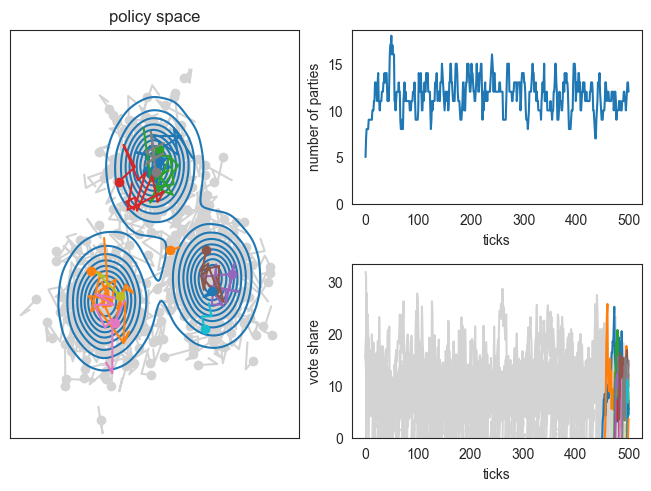

In [9]:
plot_single_run(model)
plt.show()

# question 3 - Comparison between voluntary and mandatory voting
for convenience I provide the full model again.

In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.spatial.distance import cdist

from math import pi, atan2, sin, cos, tau

from mesa import Model, Agent
from mesa.space import ContinuousSpace
from mesa.datacollection import DataCollector


class VotingModel(Model):
    """Voting model class

    Parameters
    ----------
    population_size : int
    n_parties : int
    seed : int, optional
    strategy : callable, optional

    Note that the entire implementation is based on numpy rather than pandas. The
    pure numpy implementation is more then an order of magnitude faster than an
    equivalent pandas implementation.

    """
    std = [0.1, 0.1]
    population_profile = np.asarray([[0.25, 0.25], [0.50, 0.75], [0.8, 0.33]])
    voluntary_voting = True

    def __init__(self, population_size=1e5, n_parties=5, seed=None, strategy=None, voluntary_voting=True):
        super().__init__(seed=seed)
        self.n_parties = n_parties
        self.population_size = population_size
        self.strategy = strategy

        self.space = ContinuousSpace(x_min=-2, x_max=2, y_min=-2, y_max=2, torus=False)

        self.population = Population(self, population_size)
        self.votes_per_party = {}
        self.vote_share = {}
        self.population_per_party = {}

        # create parties
        self.party_positions = {}
        for _ in range(n_parties):
            profile = self.random.choices(self.population_profile)
            position = self.rng.normal(profile, (0.15,) * 2, size=(1, 2))[0]
            self.create_new_party(position, self.strategy)

        self.seats = np.zeros((n_parties,))
        self.datacollector = DataCollector(
            agent_reporters={
                "votes": "votes",
                "x": lambda agent: agent.pos[0],
                "y": lambda agent: agent.pos[1],
                "fitness": "fitness", "vote_share": "vote_share"
            },
            model_reporters={"nr_parties": lambda model: len(model.agents),
                             "dissatisfaction": lambda model: model.population.dissatisfaction
                             }
        )

    def create_new_party(self, position, strategy=None):
        if strategy is None:
            strategy = self.random.choice([hunter, aggregator])

        party = Party(self, strategy)
        self.space.place_agent(party, position)
        self.party_positions[party] = position

    def step(self):
        """
        Run one step of the model.
        """
        election_results = self.population.vote(self.party_positions)
        votes_per_party, population_per_party = election_results
        self.votes_per_party = votes_per_party
        self.vote_share = {k: v / self.population_size for k, v in votes_per_party.items()}
        self.population_per_party = population_per_party

        self.schedule.step()

        self.datacollector.collect(self)


class Population:
    """Population agent

    Parameters
    ----------
    unique_id : int
    model : VotingModel instance
    population_size : int

    """
    alpha = 0.75
    std = [0.1, 0.1]
    beta = 0.0005  # scaling parameter to control speed of new party formation

    def __init__(
            self,  model, population_size):
        self.model = model
        self.rng = self.model.rng
        self.random = self.model.random

        sizes = [1 / 3, 1 / 3, 1 / 3]

        # establish the size of each sub population
        subpopulation_size = [int(round(entry * population_size)) for entry in sizes]

        # sample each subpopulation
        subpopulations = []
        for n_i, profile in zip(subpopulation_size, self.model.population_profile):
            subpopulation = self.rng.normal(profile, self.std,
                                                  size=(int(n_i), 2))
            subpopulations.append(subpopulation)

        # concat
        self.population = np.concatenate(subpopulations, axis=0)

        self.population_size = self.population.shape[0]
        self.dissatisfaction = np.zeros((self.population_size,), dtype=float)

    def decide_to_vote(self, distances):
        if self.model.voluntary_voting:
            distance = np.min(distances, axis=1)
            p = self.rng.random(len(self.population))
    
            return distance < p
        else:
            return np.ones(distances.shape[0], dtype=bool)

    def vote(self, party_positions):
        distances = cdist(self.population, np.vstack(list(party_positions.values())),
                          metric='sqeuclidean')

        winners = np.argmin(distances, axis=1)
        self.dissatisfaction = self.alpha * self.dissatisfaction + (1 - self.alpha) * np.min(distances, axis=1)

        new_parties = self.rng.random(len(self.population)) < self.beta * self.dissatisfaction
        positions = self.population[new_parties]
        for position in positions:
            self.model.create_new_party(position, strategy=self.model.strategy)

        is_voting = self.decide_to_vote(distances)
        votes_per_party = {}
        population_per_party = {}
        for i, party in enumerate(party_positions.keys()):
            subpopulation = self.population[(winners == i) & (is_voting)]
            population_per_party[party] = subpopulation
            votes_per_party[party] = subpopulation.shape[0]

        return votes_per_party, population_per_party


class Party(Agent):
    """Party agent

    Parameters
    ----------
    unique_id : int
    model : VotingModel instance
    strategy : callable
    policy_position : 2 tuple
    alpha : float

    """
    survival_threshold = 5

    @property
    def vote_share(self):
        return (self.votes / self.model.population_size) * 100

    def __init__(self, model, strategy, alpha=0.5):
        super().__init__(model)
        self.votes = 0
        self.strategy = strategy
        self.alpha = alpha
        self.fitness = 100
        self.direction = 0.035 * np.array([self.random.random(), self.model.random.random()])

    def step(self):
        votes = self.model.votes_per_party[self]
        population = self.model.population_per_party[self]
        vote_share = votes / self.model.population_size * 100

        # update fitness
        self.fitness = self.alpha * self.fitness + (1 - self.alpha) * vote_share

        if self.fitness < self.survival_threshold:
            self.model.space.remove_agent(self)
            self.model.party_positions.pop(self)
            self.model.schedule.remove(self)
            self.remove()
            return

        new_position = self.strategy(self, votes, population)

        self.votes = votes
        self.direction = new_position - self.pos
        self.model.space.move_agent(self, new_position)
        self.model.party_positions[self] = self.pos


def sticker(party, votes, population):
    return party.pos


def hunter(party, votes, population):
    if votes > party.votes:
        return party.pos + party.direction
    else:
        # flip direction
        x, y = party.direction
        try:
            direction_radians = atan2(y, x)
        except ZeroDivisionError:
            new_direction = party.random.random() * 2 * pi
        else:
            flip_direction = (direction_radians + pi) % tau

            new_direction = party.random.uniform(flip_direction - 0.5 * pi, flip_direction + 0.5 * pi)

        x, y = 0.05 * cos(new_direction), 0.05 * sin(new_direction)

    return party.pos + np.array([x, y])


def aggregator(party, votes, population):
    if votes > 0:
        return np.mean(population, axis=0)
    else:
        return party.pos


# Use only this code and the first rendering of the model. The second given version has bugs.

In [23]:

# ── Run experiments: 5 seeds × 2 conditions × 250 ticks ──────────────────────
N_SEEDS = 5
N_TICKS = 250

models_voluntary  = []
models_obligatory = []

for seed in range(N_SEEDS):
    m_vol = VotingModel(n_parties=5, seed=seed, voluntary_voting=True)
    for _ in range(N_TICKS):
        m_vol.step()
    models_voluntary.append(m_vol)

    m_obl = VotingModel(n_parties=5, seed=seed, voluntary_voting=False)
    for _ in range(N_TICKS):
        m_obl.step()
    models_obligatory.append(m_obl)

print("Experiments complete.")

Experiments complete.


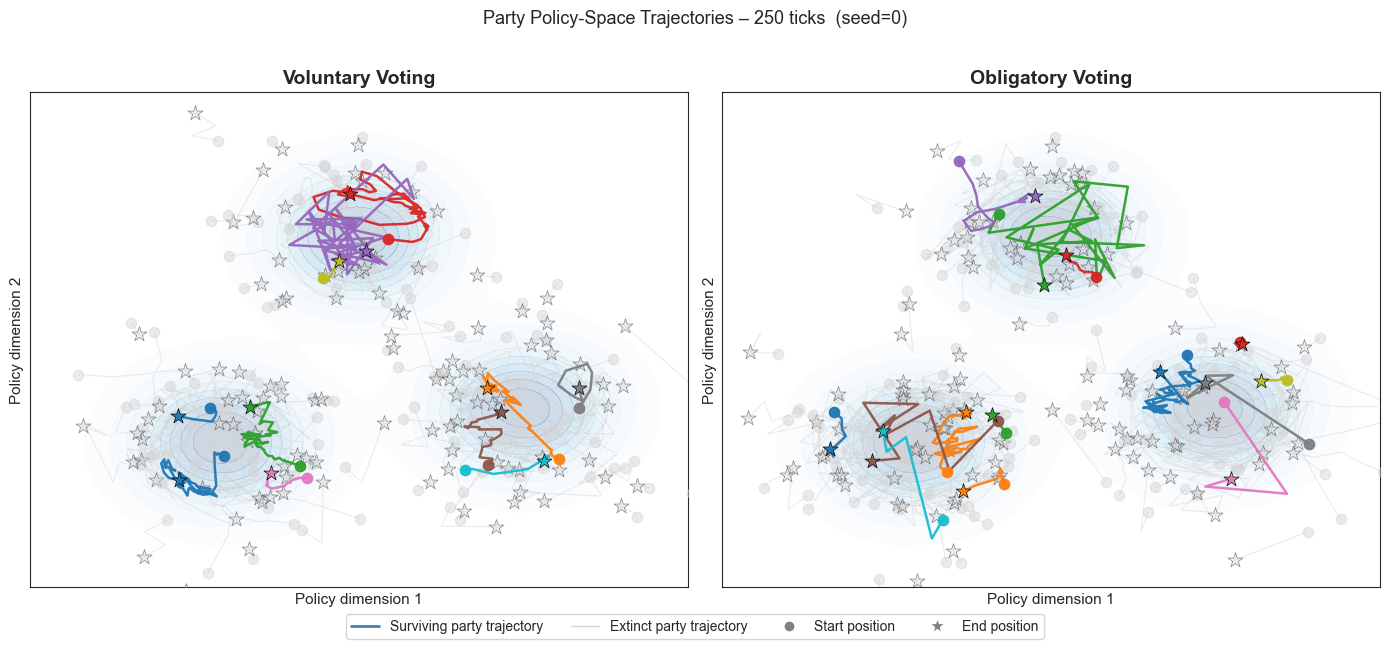

In [24]:
# ── 3b) Visualization: policy-space trajectories ─────────────────────────────
from matplotlib.lines import Line2D

def plot_position_comparison(m_vol, m_obl, seed_label=0):
    pop = m_vol.population.population   # same voter distribution (same seed)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    conditions = [("Voluntary Voting",  m_vol, axes[0]),
                  ("Obligatory Voting", m_obl, axes[1])]

    for title, model, ax in conditions:
        agent_data = model.datacollector.get_agent_vars_dataframe()
        last_tick  = agent_data.index.max()[0]
        alive      = set(agent_data.loc[last_tick].index.values)

        # voter density background
        sns.kdeplot(x=pop[:, 0], y=pop[:, 1], ax=ax,
                    fill=True, alpha=0.20, zorder=1, cmap="Blues")

        colors = itertools.cycle(sns.color_palette("tab10"))

        for party_id, pdata in agent_data.groupby("AgentID"):
            if party_id in alive:
                c, zo, lw, a = next(colors), 10, 1.8, 0.95
            else:
                c, zo, lw, a = "lightgrey", 2, 0.8, 0.45

            xs, ys = pdata["x"].values, pdata["y"].values
            ax.plot(xs, ys, color=c, zorder=zo, lw=lw, alpha=a)
            ax.scatter(xs[0],  ys[0],  color=c, zorder=zo+1, s=55,
                       marker="o", alpha=a)                         # start
            ax.scatter(xs[-1], ys[-1], color=c, zorder=zo+1, s=130,
                       marker="*", edgecolors="black",
                       linewidths=0.5, alpha=a)                     # end

        ax.set_xlim(-0.1, 1.1);  ax.set_ylim(-0.1, 1.1)
        ax.set_title(title, fontsize=14, fontweight="bold")
        ax.set_xlabel("Policy dimension 1", fontsize=11)
        ax.set_ylabel("Policy dimension 2", fontsize=11)
        ax.tick_params(left=False, bottom=False,
                       labelleft=False, labelbottom=False)

    legend_elements = [
        Line2D([0],[0], color="steelblue", lw=2,
               label="Surviving party trajectory"),
        Line2D([0],[0], color="lightgrey",  lw=1,
               label="Extinct party trajectory"),
        Line2D([0],[0], marker="o", color="w",
               markerfacecolor="grey", markersize=8, label="Start position"),
        Line2D([0],[0], marker="*", color="w",
               markerfacecolor="grey", markersize=12, label="End position"),
    ]
    fig.legend(handles=legend_elements, loc="lower center", ncol=4,
               fontsize=10, bbox_to_anchor=(0.5, -0.04))

    plt.suptitle(
        f"Party Policy-Space Trajectories – 250 ticks  (seed={seed_label})",
        fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


plot_position_comparison(models_voluntary[0], models_obligatory[0], seed_label=0)

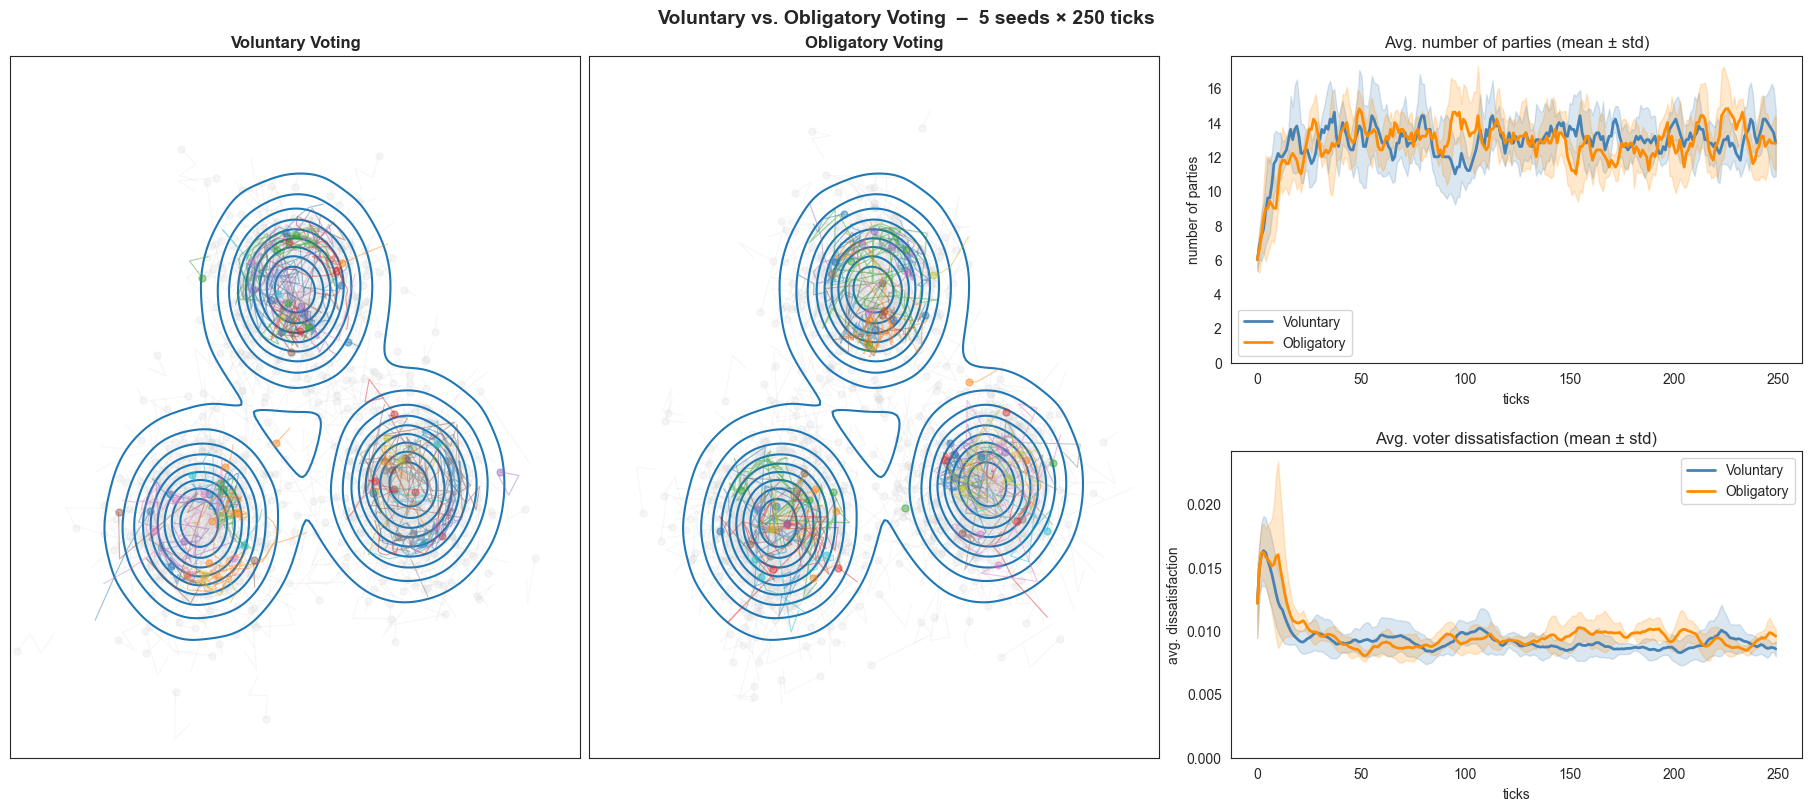

In [25]:
def plot_multi_run_comparison(models_vol, models_obl):
    """
    Mirrors plot_single_run's layout but across multiple seeds:
      - Left two panels : policy-space trajectories (all seeds overlaid)
      - Top-right       : avg number of parties ± std  (both conditions)
      - Bottom-right    : avg voter dissatisfaction ± std (both conditions)
    """
    sns.set_style('white')
    pop = models_vol[0].population.population   # representative voter cloud

    fig = plt.figure(figsize=(18, 8), constrained_layout=True)
    gs  = GridSpec(2, 6, figure=fig)

    ax_vol = fig.add_subplot(gs[:, 0:2])   # policy space – voluntary
    ax_obl = fig.add_subplot(gs[:, 2:4])   # policy space – obligatory
    ax_top = fig.add_subplot(gs[0, 4:])    # number of parties
    ax_bot = fig.add_subplot(gs[1, 4:])    # dissatisfaction

    # ── Policy-space panels (all seeds overlaid) ─────────────────────────
    for ax, models, title in [
        (ax_vol, models_vol, "Voluntary Voting"),
        (ax_obl, models_obl, "Obligatory Voting"),
    ]:
        ax.set_xlim(-0.25, 1.25);  ax.set_ylim(-0.25, 1.25)
        sns.kdeplot(x=pop[:, 0], y=pop[:, 1], ax=ax, zorder=5)

        for model in models:
            agent_data = model.datacollector.get_agent_vars_dataframe()
            last_tick  = agent_data.index.max()[0]
            alive      = set(agent_data.loc[last_tick].index.values)
            colors     = itertools.cycle(sns.color_palette())

            for party_id, pdata in agent_data.groupby('AgentID'):
                if party_id not in alive:
                    c, zo, a = "lightgrey", 1, 0.2
                else:
                    c, zo, a = next(colors), 10, 0.45
                x, y = pdata.x.values, pdata.y.values
                ax.plot(x, y, c=c, zorder=zo, alpha=a, lw=0.8)
                ax.scatter(x[-1], y[-1], color=c, zorder=zo, alpha=a, s=25)

        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xticks([]);  ax.set_yticks([])

    # ── Aggregate statistics (mean ± std across seeds) ───────────────────
    for models, label, color in [
        (models_vol, "Voluntary",  "steelblue"),
        (models_obl, "Obligatory", "darkorange"),
    ]:
        dfs = [m.datacollector.get_model_vars_dataframe() for m in models]

        # number of parties
        nr  = np.array([df['nr_parties'].values for df in dfs])
        mn, sd = nr.mean(axis=0), nr.std(axis=0)
        t = np.arange(len(mn))
        ax_top.plot(t, mn, color=color, lw=2, label=label)
        ax_top.fill_between(t, mn - sd, mn + sd, alpha=0.2, color=color)

        # mean voter dissatisfaction per tick (stored as per-voter array)
        dis = np.array([df['dissatisfaction'].apply(np.mean).values for df in dfs])
        mn, sd = dis.mean(axis=0), dis.std(axis=0)
        ax_bot.plot(t, mn, color=color, lw=2, label=label)
        ax_bot.fill_between(t, mn - sd, mn + sd, alpha=0.2, color=color)

    ax_top.set_ylabel('number of parties');    ax_top.set_xlabel('ticks')
    ax_top.set_ylim(ymin=0);                   ax_top.legend()
    ax_top.set_title('Avg. number of parties (mean ± std)')

    ax_bot.set_ylabel('avg. dissatisfaction');  ax_bot.set_xlabel('ticks')
    ax_bot.set_ylim(ymin=0);                    ax_bot.legend()
    ax_bot.set_title('Avg. voter dissatisfaction (mean ± std)')

    plt.suptitle(
        f'Voluntary vs. Obligatory Voting  –  {len(models_vol)} seeds × 250 ticks',
        fontsize=14, fontweight='bold'
    )
    plt.show()


plot_multi_run_comparison(models_voluntary, models_obligatory)